In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
df = pd.read_csv('Titanic-Dataset.csv')

In [183]:
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Embarked     891 non-null    object 
 7   FamilySize   891 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [ ]:
df['Age'] = df['Age'].astype('int64')

In [184]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

As we can see there are some missing values in "cabin", "Age", "Embarked" columns that we need to either drop or fill  

In [185]:
df['Embarked'].value_counts()
df['Embarked'].fillna('S', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_2012\2351840006.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S', inplace=True)


In [186]:
df.drop(columns=['Ticket', 'Cabin'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


In [187]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1   # to show overall family size
df.drop(columns=['Ticket', 'Name', 'Cabin', 'SibSp', 'Parch'], inplace=True)
df

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,1,0,3,male,22.0,7.2500,S,2
1,2,1,1,female,38.0,71.2833,C,2
2,3,1,3,female,26.0,7.9250,S,1
3,4,1,1,female,35.0,53.1000,S,2
4,5,0,3,male,35.0,8.0500,S,1
...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,13.0000,S,1
887,888,1,1,female,19.0,30.0000,S,1
888,889,0,3,female,NaN,23.4500,S,4
889,890,1,1,male,26.0,30.0000,C,1


In [188]:
df['Age'] = df['Age'].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
FamilySize     0
dtype: int64


Now there are no Missing or Null values, so the data is pretty clean and can be used to train models on

#### Lets plot some data to have some insights on some of the correlations between the features and the target 

In [ ]:
col=['Embarked','Pclass','Sex','FamilySize']
for i in col:
    print('Survival Correlation by:', i)
    df2=df.groupby(i)['Survived'].mean().reset_index()
    print(df2)
    print('-'*10, '\n')

Survival Correlation by: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
---------- 

Survival Correlation by: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Survival Correlation by: Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
---------- 

Survival Correlation by: FamilySize
   FamilySize  Survived
0           1  0.303538
1           2  0.552795
2           3  0.578431
3           4  0.724138
4           5  0.200000
5           6  0.136364
6           7  0.333333
7           8  0.000000
8          11  0.000000
---------- 

Survival Correlation by: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
---------- 



This plot lets us see relationships between numeric features

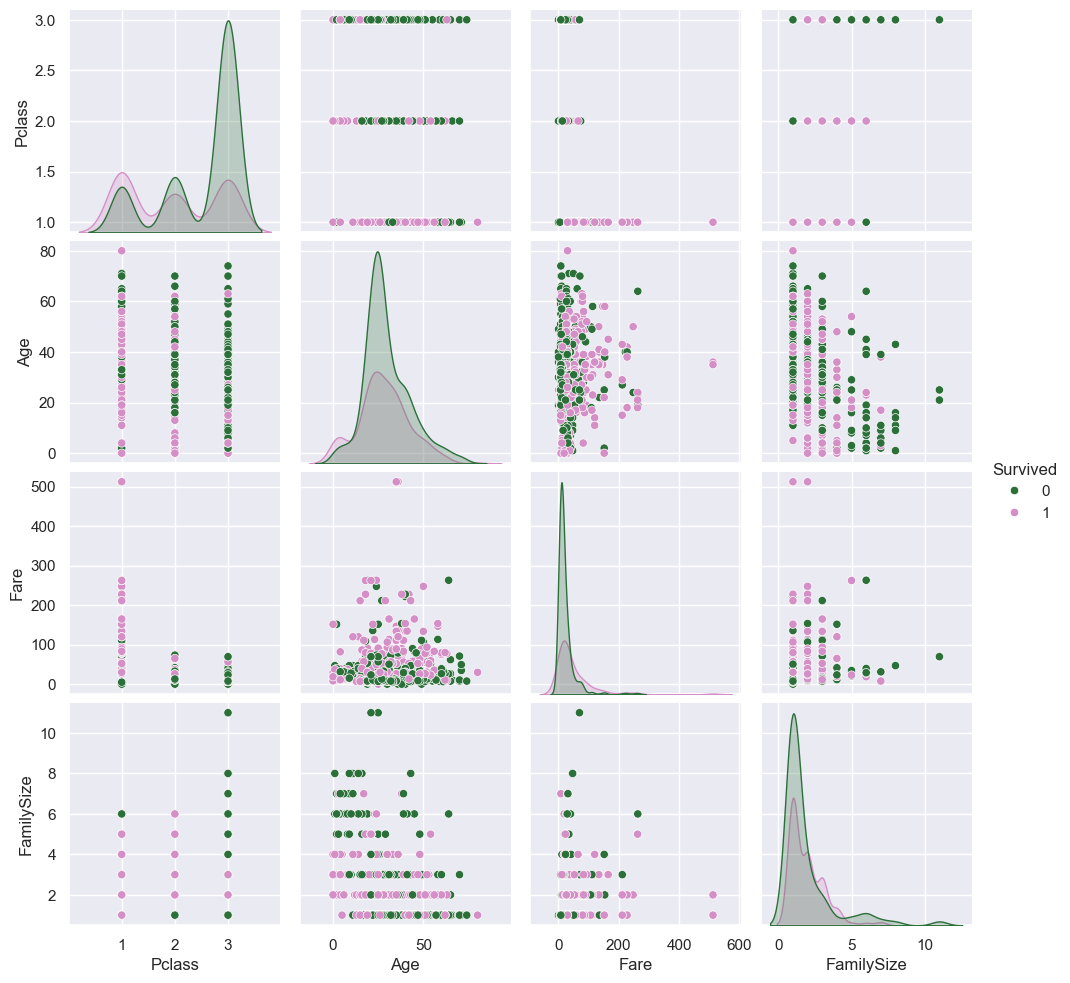

In [215]:
sns.pairplot(data=df, vars=['Pclass', 'Age','Fare','FamilySize'], hue='Survived', kind='scatter', palette='cubehelix')

From this plot we can see that people from 1st Pclass survive significantly more. People who's fare is bigger also survive more (mainly due to the cost of the tickets for different classes and the 1st class surviving more as we previously stated). Families with 2-4 members survive more frequent on average. 

<Axes: xlabel='Sex', ylabel='count'>

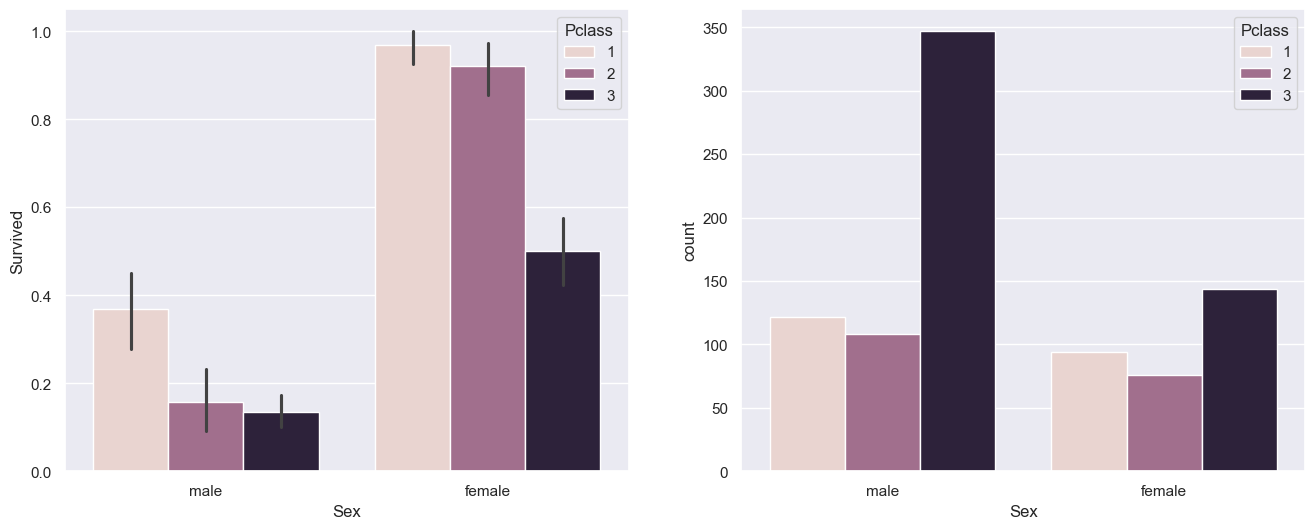

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))
sns.barplot(data=df, x='Sex',y='Survived', hue='Pclass', ax=axs[0])
sns.countplot(data=df, x='Sex', hue='Pclass', ax=axs[1])


This plot above gives us an obvious point that people with 1st class are way more likely to survive... 
This plot also shows us that women were way more likely to survive as well.

The next plot is a heatmap that shows pearson correlation between features

<Axes: >

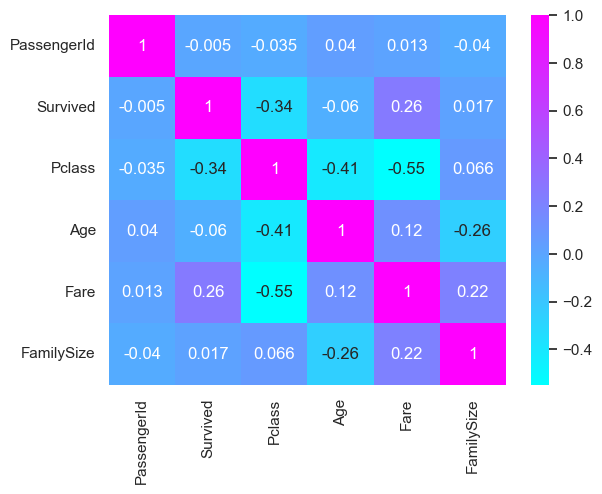

In [193]:
sns.heatmap(df.corr(numeric_only=True), cmap='cool', annot=True)

In [194]:
df.drop(columns='PassengerId')

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,male,22,7.2500,S,2
1,1,1,female,38,71.2833,C,2
2,1,3,female,26,7.9250,S,1
3,1,1,female,35,53.1000,S,2
4,0,3,male,35,8.0500,S,1
...,...,...,...,...,...,...,...
886,0,2,male,27,13.0000,S,1
887,1,1,female,19,30.0000,S,1
888,0,3,female,21,23.4500,S,4
889,1,1,male,26,30.0000,C,1


#### Here is the ML part where i train my RandomForestClassifier

In [216]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

In [196]:
col_transformation = ColumnTransformer(
    [
        ('scaling', MinMaxScaler(), [2,3]),
        ('OneHotEncoding', OneHotEncoder(), [1, 4]),
        ('ordinal', OrdinalEncoder(), [0])
    ],
    remainder='passthrough'
)


In [201]:
train, test = train_test_split(df, test_size=0.2)
X_train = train[['Pclass',	'Sex', 'Age',	'Fare',	'Embarked',	'FamilySize']]
y_train = train['Survived']
X_test = test[['Pclass',	'Sex', 'Age',	'Fare',	'Embarked',	'FamilySize']]
y_test = test['Survived']

In [ ]:
def create_pipeline(algo):
    return Pipeline(steps=[
        ('num_cat_transformation', col_transformation),
        ('classifier', algo)
    ])

In [221]:
pipeline = create_pipeline(RandomForestClassifier(n_estimators=200))
scores = cross_val_score(pipeline, X_train, y_train, cv=10)

In [222]:
scores

array([0.84722222, 0.81944444, 0.77464789, 0.78873239, 0.8028169 ,
       0.84507042, 0.74647887, 0.73239437, 0.83098592, 0.78873239])

In [223]:
scores.mean()

0.7976525821596244

In the cell above we can see our cross-validation scores for RandomForestClassifier. It shows ~0.8 accuracy. Not that bad but it could be better :)